# Lab 4.06 - Bivariate Analysis of Qualitative Data


In [1]:
# Importing the necessary packages
import numpy as np                                  # "Scientific computing"
import scipy.stats as stats                         # Statistical tests

import pandas as pd                                 # Data Frame
from pandas.api.types import CategoricalDtype

import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic diagram
import seaborn as sns                               # Advanced data visualisation

## Exercise 6 - Influence of background music on purchasing behaviour

Market research shows that background music in a supermarket can influence the purchasing behaviour of customers. A study compared three methods: no music, French chansons and Italian hits. In each case, the number of bottles of French, Italian and other wines sold was counted (Ryan, et al., 1998).

The research data can be found in the file data/MuziekWijn.csv.

1. Set up the correct crosstab.
2. Determine the marginal totals.
3. Determine the expected results.
4. Calculate the χ² test statistic.
5. Calculate Cramér's V. What can you conclude from this?

Visualize the data set:

1. Plot a bar chart showing the percentages of types of wine sold when no music was playing.
2. Plot a clustered bar chart of the dataset
3. Plot a bar chart (stacked bar chart) of the dataset

Results of the main calculations (rounded up to 3 decimal places):

* χ² ≈ 18.279
* Cramér's V ≈ 0.194

In [60]:
muziek_wijn = pd.read_csv("https://raw.githubusercontent.com/HoGentTIN/dsai-labs/refs/heads/main/data/MuziekWijn.csv")
muziek_wijn.head()

,Muziek,Wijn
0,Geen,Franse
1,Franse,Franse
2,Franse,Italiaanse
3,Italiaanse,Andere
4,Italiaanse,Franse


Read the dataset

Give the names of both columns. What is wrong?

In [61]:
print(muziek_wijn.columns) # Leading space in 'Wijn'
muziek_wijn = muziek_wijn.rename(columns={' Wijn': 'Wijn'})
print(muziek_wijn.columns)


Index(['Muziek', ' Wijn'], dtype='object')
Index(['Muziek', 'Wijn'], dtype='object')


In [62]:
muziek_wijn.head()

,Muziek,Wijn
0,Geen,Franse
1,Franse,Franse
2,Franse,Italiaanse
3,Italiaanse,Andere
4,Italiaanse,Franse


You can change the name of a column 'ab' to the column 'abc' of the dataframe df, using the following command

`df = df.rename(columns={'ab': 'abc'})`

Use this command to change the column name.  
Check afterwards if the result is correct.

1. Set up the correct crosstab.

In [9]:
observed = pd.crosstab(muziek_wijn.Wijn, muziek_wijn.Muziek)
observed

Muziek,Franse,Geen,Italiaanse
Wijn,,,
Andere,35,43,35
Franse,39,30,30
Italiaanse,1,11,19


2. Determine the marginal totals.

In [13]:
row_sums = observed.sum(axis=1)
col_sums = observed.sum()
n = row_sums.sum()

print(row_sums)
print()
print(col_sums)
print()
print(f'Number of observations: {n}')

Wijn
Andere        113
Franse         99
Italiaanse     31
dtype: int64

Muziek
Franse        75
Geen          84
Italiaanse    84
dtype: int64

Number of observations: 243


3. Determine the expected results.

In [14]:
expected = np.outer(row_sums, col_sums) / n
expected

array([[34.87654321, 39.0617284 , 39.0617284 ],
       [30.55555556, 34.22222222, 34.22222222],
       [ 9.56790123, 10.71604938, 10.71604938]])

In [15]:
diffs = (expected - observed)**2 / expected
diffs

Muziek,Franse,Geen,Italiaanse
Wijn,,,
Andere,0.000437,0.397063,0.422348
Franse,2.333737,0.520924,0.520924
Italiaanse,7.672417,0.007524,6.403837


4. Calculate the χ² test statistic.

In [16]:
chi_squared = diffs.values.sum()
print('χ² ≈ %.3f' %chi_squared)

χ² ≈ 18.279


5. Calculate Cramér's V. What can you conclude from this?

In [17]:
stats.contingency.association(observed, method='cramer')
# -> Small association between played background music and bought wine

0.19393696480652944

Plot a bar chart showing the percentages of types of wine sold when no music was playing.

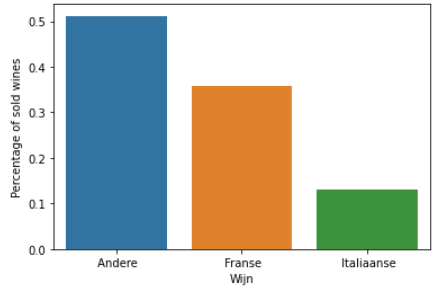

In [48]:
df_help = muziek_wijn[muziek_wijn['Muziek'] == 'Geen'].groupby('Wijn').count().reset_index()

totaal = df_help['Muziek'].sum()
df_help['procentueel'] = df_help['Muziek'] / totaal

df_help.head()

,Wijn,Muziek,procentueel
0,Andere,43,0.511905
1,Franse,30,0.357143
2,Italiaanse,11,0.130952


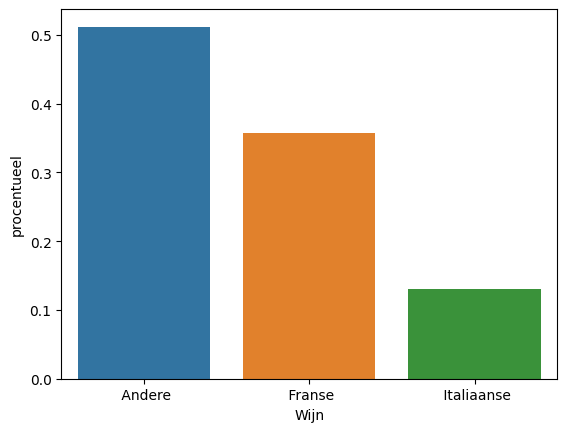

In [56]:
sns.barplot(data=df_help, x='Wijn', y='procentueel', hue='Wijn');

,Muziek,Wijn
0,Geen,Franse
1,Franse,Franse
2,Franse,Italiaanse
3,Italiaanse,Andere
4,Italiaanse,Franse


Plot a clustered bar chart of the dataset  

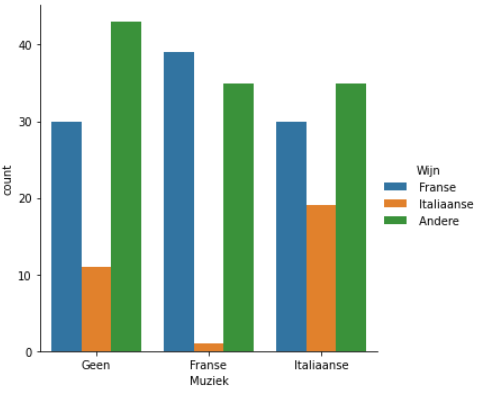

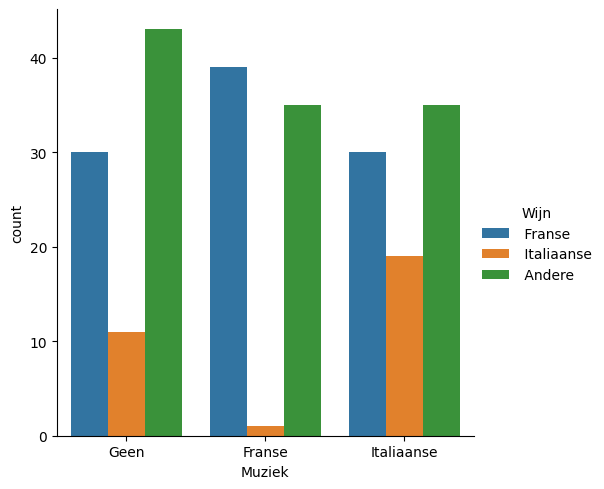

In [64]:
sns.catplot(data=muziek_wijn, x='Muziek', hue='Wijn', kind='count');

Plot a bar chart (stacked bar chart) of the dataset

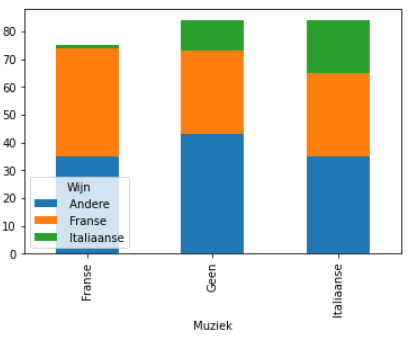

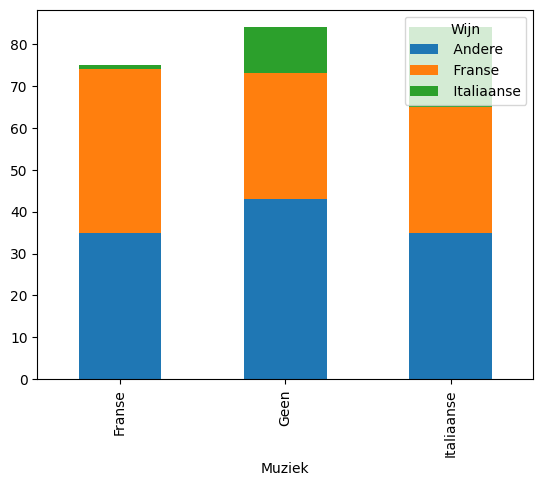

In [71]:
observed.T.plot(kind='bar', stacked=True);